# **Heart Failure - EDA**

**1. Setup Inicial - Bibliotecas e Dataset**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np 
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None) # mostra todas as colunas

# carrega o dataset
df = pd.read_csv("heart_failure_clinical_records_dataset.csv")

df.sample(5) # 5 linhas aleatórias (melhor que head, evita viés do início)

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
147,64.0,0,1610,0,60,0,242000.0,1.0,137,1,0,113,0
131,60.0,1,1082,1,45,0,250000.0,6.1,131,1,0,107,0
41,50.0,0,124,1,30,1,153000.0,1.2,136,0,1,32,1
177,49.0,1,69,0,50,0,132000.0,1.0,140,0,0,147,0
282,42.0,0,64,0,30,0,215000.0,3.8,128,1,1,250,0


**2. Análise Geral**

In [19]:
print(f"Dimensões: {df.shape}") # mostra as dimensões do dataset
print(f"\nColunas: {df.columns.tolist()}") # coloca todas as colunas do dataset em uma lista

Dimensões: (299, 13)

Colunas: ['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes', 'ejection_fraction', 'high_blood_pressure', 'platelets', 'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time', 'DEATH_EVENT']


1. Quantas linhas e colunas tem? É um dataset grande ou pequeno?
É um dataset pequeno, contendo 299 linhas e 13 colunas.

2. Olhando os nomes das colunas, qual você acha que é a coluna alvo (a que você gostaria de prever)?
Death_Event

3. Alguma coluna parece que vai ser difícil de entender sem contexto médico?
Ejection_fraction, Platelets, Serum_Creatinine, Serum_Sodium, Creatinine_phosphokinase

**O dicionário do dataset**

**As colunas se dividem em três grupos:**
- Demográficas e hábitos: age (idade), sex (1 = homem, 0 = mulher), smoking (fuma ou não).
- Condições pré-existentes (binárias, 0 ou 1): anaemia (anemia — falta de hemoglobina), diabetes, high_blood_pressure (hipertensão).

**Exames clínicos:**
- ejection_fraction — o % de sangue que o coração bombeia a cada batida. Essa é provavelmente a mais importante do dataset. Coração saudável fica em torno de 50-70%. Valores baixos (como o 20 que aparece na sua amostra) indicam coração fraco.
- serum_creatinine — creatinina no sangue. Mede função renal. Quanto mais alto, pior o rim está funcionando.
- serum_sodium — sódio no sangue. Sódio baixo é sinal de gravidade em pacientes cardíacos.
- platelets — plaquetas (coagulação do sangue).
- creatinine_phosphokinase (CPK) — enzima que, elevada, indica dano muscular/cardíaco.

**Especial:**
- time — dias de acompanhamento do paciente no estudo. Atenção a essa coluna, ela tem uma armadilha que vamos discutir mais à frente.
- Alvo: DEATH_EVENT — 1 = o paciente faleceu durante o acompanhamento, 0 = sobreviveu.

In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB


**O que o info() revela**

Dataset impecável em termos de limpeza: 299 linhas, todas as 13 colunas com 299 valores não-nulos. Ou seja, zero nulos. E os tipos estão todos coerentes (números como número). Isso significa que você pode pular boa parte da etapa de tratamento — não há nulos para preencher nem tipos para corrigir. Na vida real isso é raro, aproveita.

In [21]:
df.describe()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.00000,299.000000,299.000000,299.00000,299.000000,299.00000
mean,60.833893,0.431438,581.839465,0.418060,38.083612,0.351171,263358.029264,1.39388,136.625418,0.648829,0.32107,130.260870,0.32107
std,11.894809,0.496107,970.287881,0.494067,11.834841,0.478136,97804.236869,1.03451,4.412477,0.478136,0.46767,77.614208,0.46767
min,40.000000,0.000000,23.000000,0.000000,14.000000,0.000000,25100.000000,0.50000,113.000000,0.000000,0.00000,4.000000,0.00000
25%,51.000000,0.000000,116.500000,0.000000,30.000000,0.000000,212500.000000,0.90000,134.000000,0.000000,0.00000,73.000000,0.00000
50%,60.000000,0.000000,250.000000,0.000000,38.000000,0.000000,262000.000000,1.10000,137.000000,1.000000,0.00000,115.000000,0.00000
75%,70.000000,1.000000,582.000000,1.000000,45.000000,1.000000,303500.000000,1.40000,140.000000,1.000000,1.00000,203.000000,1.00000
max,95.000000,1.000000,7861.000000,1.000000,80.000000,1.000000,850000.000000,9.40000,148.000000,1.000000,1.00000,285.000000,1.00000


**O que o describe() revela (aqui mora a criticidade)**

Vamos olhar variável por variável com senso crítico:
- age — min 40, max 95, média ~61. Plausível para um estudo de insuficiência cardíaca (doença de idosos). Sem valores absurdos.
- ejection_fraction — vai de 14 a 80, média 38. Lembra que coração saudável fica em 50-70%? A média de 38% já é baixa — faz sentido, são todos pacientes cardíacos. Isso é interessante.
- creatinine_phosphokinase — olha a variação: min 23, max 7861, mas a mediana (50%) é só 250. Isso é um sinal clássico de distribuição muito enviesada com outliers extremos. A média (581) está puxada para cima por poucos valores altíssimos. Vamos ver isso no boxplot.
- platelets — mesma história: varia de 25.100 a 850.000. Escala enorme.
- Variáveis binárias (anaemia, diabetes, etc.) — a média representa a proporção. Ex: diabetes com média 0.42 significa que 42% dos pacientes têm diabetes Bom truque para ler binárias no describe.

In [22]:
# como o alvo está distribuído? (quantos morreram vs sobreviveram)
df["DEATH_EVENT"].value_counts()

DEATH_EVENT
0    203
1     96
Name: count, dtype: int64

**O alerta importante — o desbalanceamento**

O value_counts() mostra: 203 sobreviveram (0) contra 96 que faleceram (1). Isso dá cerca de 68% vs 32% — a base é desbalanceada.
Por que isso importa? Imagina criar um modelo burro que sempre prevê "sobrevive". Ele acertaria 68% das vezes sem aprender nada. Por isso, em bases desbalanceadas, acurácia sozinha engana — precisamos olhar outras métricas (que veremos em ML).

**3. Tratamento dos Dados**

**Tratamentos possíveis:**

**Nulos:**

- Remover linhas com nulos (use se forem poucas): **df = df.dropna()**
- Preencher numérico com a mediana (mais robusta que a média a outliers): **df["coluna"] = df["coluna"].fillna(df["coluna"].median())**
- Preencher categórico com o valor mais comum (moda): **df["coluna"] = df["coluna"].fillna(df["coluna"].mode()[0])**

Critério de decisão: se uma coluna tem >40% de nulos, considere remover a coluna inteira. Se são
poucas linhas, remova as linhas.

Como esse Dataset não tem nulos, pulamos esta parte.

**Duplicatas:**
- print("Duplicatas:", df.duplicated().sum())
- df = df.drop_duplicates()

**Padronização de texto (ANTES de mapear):**

Remove espaços e padroniza maiúsculas — evita "Surgery" != "surgery ":
- df["coluna"] = df["coluna"].str.strip().str.title()

**Conversão de categóricas para números (quando fizer sentido
ordinal)**
- df["estagio"] = df["estagio"].map({
    "Stage I": 1, "Stage Ii": 2, "Stage Iii": 3, "Stage Iv": 4
    })


In [23]:
print(df.isnull().sum()) # conta nulos por coluna

age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64


In [24]:
print("Duplicatas:", df.duplicated().sum())
df = df.drop_duplicates()

Duplicatas: 0


**4. Análise univariada (uma variável por vez)**

Entender a distribuição de cada variável isoladamente.

**Variáveis numéricas → Histograma + Boxplot**

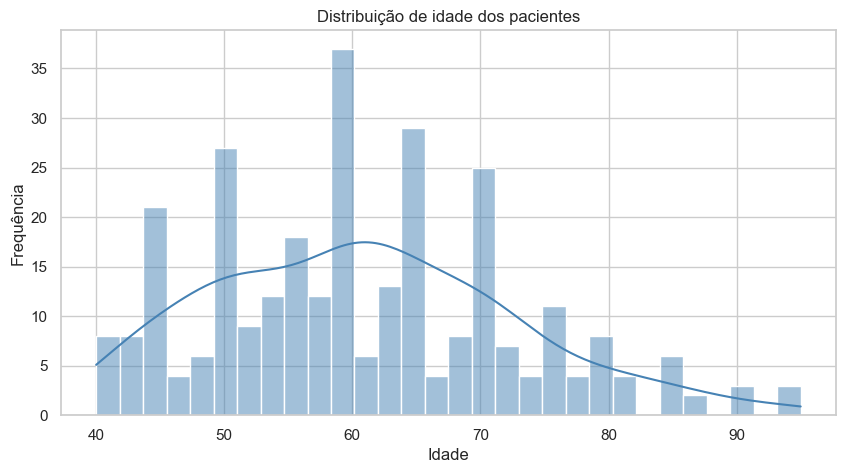

In [31]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x="age", bins=30, kde=True, color="steelblue")
plt.title("Distribuição de idade dos pacientes")
plt.xlabel("Idade")
plt.ylabel("Frequência")
plt.show()

A população do estudo concentra-se entre 50 e 70 anos, com mediana em torno de 60, coerente com o perfil epidemiológico da insuficiência cardíaca.

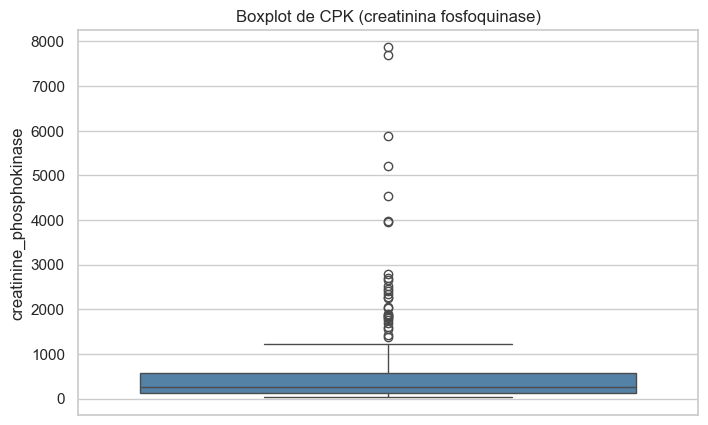

In [34]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, y="creatinine_phosphokinase", color="steelblue")
plt.title("Boxplot de CPK (creatinina fosfoquinase)")
plt.show()

Variáveis com outliers extremos assim às vezes precisam de transformação (tipo log) antes de entrar num modelo, se não distorcem tudo.

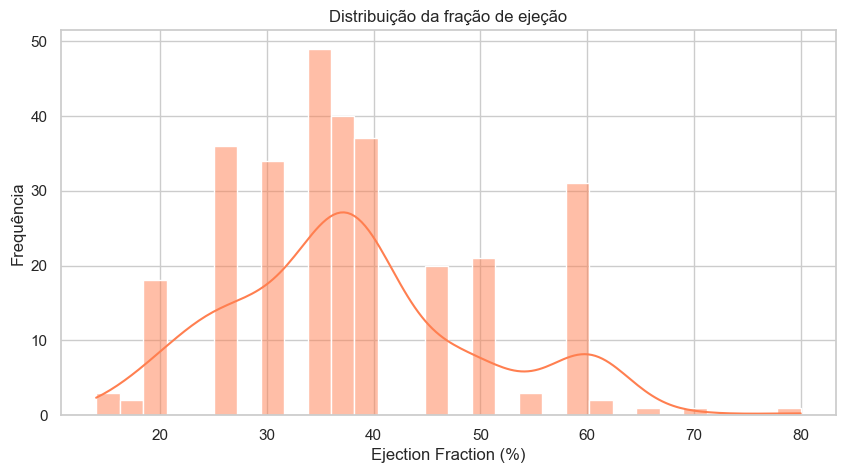

In [35]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x="ejection_fraction", bins=30, kde=True, color="coral")
plt.title("Distribuição da fração de ejeção")
plt.xlabel("Ejection Fraction (%)")
plt.ylabel("Frequência")
plt.show()

A fração de ejeção apresenta distribuição bimodal, sugerindo dois perfis distintos de pacientes — um com função cardíaca severamente reduzida (~35%) e outro com função preservada (~60%).

**5. Análise bivariada (CRUZAR com a coluna alvo)**


C:\Users\berna\AppData\Local\Temp\ipykernel_18596\178440845.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="DEATH_EVENT", y="ejection_fraction", palette="Set2")


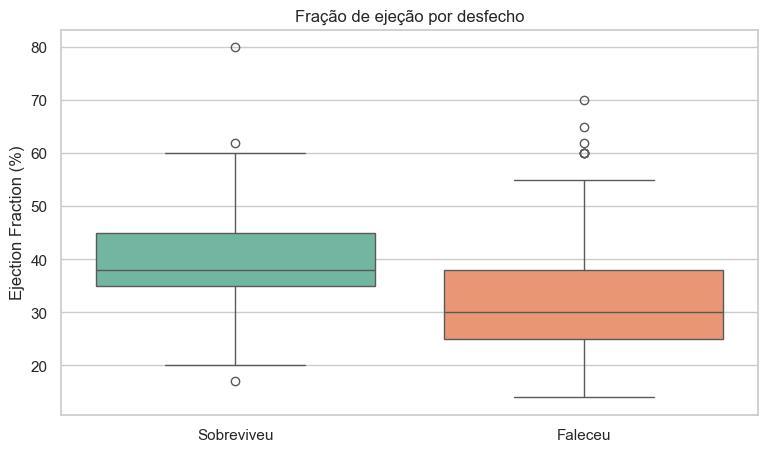

In [36]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x="DEATH_EVENT", y="ejection_fraction", palette="Set2")
plt.title("Fração de ejeção por desfecho")
plt.xticks([0, 1], ["Sobreviveu", "Faleceu"])
plt.xlabel("")
plt.ylabel("Ejection Fraction (%)")
plt.show()

A fração de ejeção mediana dos que faleceram (~30%) é significativamente menor que a dos sobreviventes (~38%), confirmando que a capacidade de bombeamento cardíaco é um forte preditor de mortalidade.

C:\Users\berna\AppData\Local\Temp\ipykernel_18596\2326498130.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="DEATH_EVENT", y="age", palette="Set2")


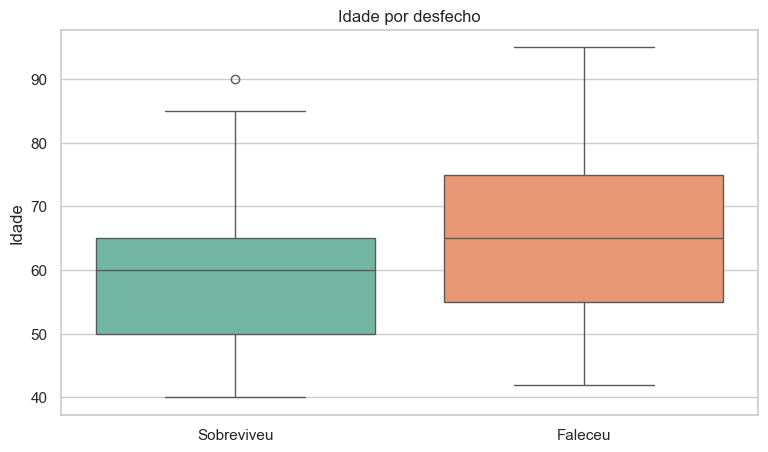

In [37]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x="DEATH_EVENT", y="age", palette="Set2")
plt.title("Idade por desfecho")
plt.xticks([0, 1], ["Sobreviveu", "Faleceu"])
plt.xlabel("")
plt.ylabel("Idade")
plt.show()

A idade mediana dos que faleceram (65) é cerca de 5 anos maior que a dos sobreviventes (60), indicando influência moderada da idade no desfecho.

C:\Users\berna\AppData\Local\Temp\ipykernel_18596\2617101906.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="DEATH_EVENT", y="serum_creatinine", palette="Set2")


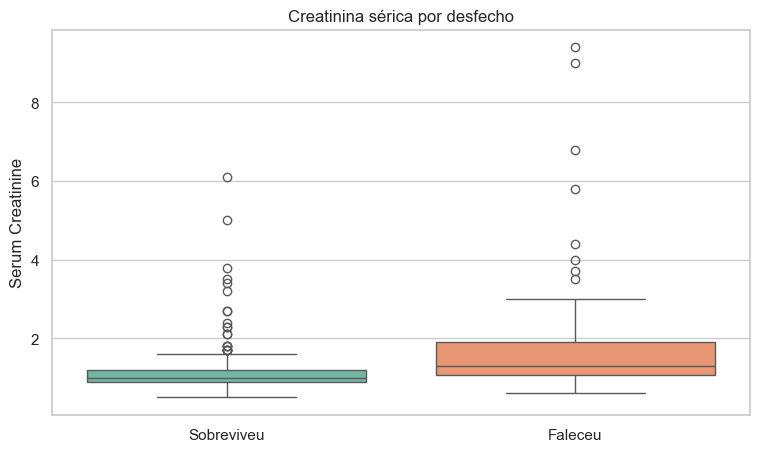

In [38]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x="DEATH_EVENT", y="serum_creatinine", palette="Set2")
plt.title("Creatinina sérica por desfecho")
plt.xticks([0, 1], ["Sobreviveu", "Faleceu"])
plt.xlabel("")
plt.ylabel("Serum Creatinine")
plt.show()

Pacientes que faleceram apresentaram creatinina sérica mediana mais elevada (~1.4 vs ~1.0), sugerindo que o comprometimento renal acompanha o agravamento do quadro cardíaco.

In [39]:
df.groupby("DEATH_EVENT")[["ejection_fraction", "age", "serum_creatinine"]].mean()

,ejection_fraction,age,serum_creatinine
DEATH_EVENT,,,
0,40.26601,58.761906,1.184877
1,33.46875,65.215281,1.835833


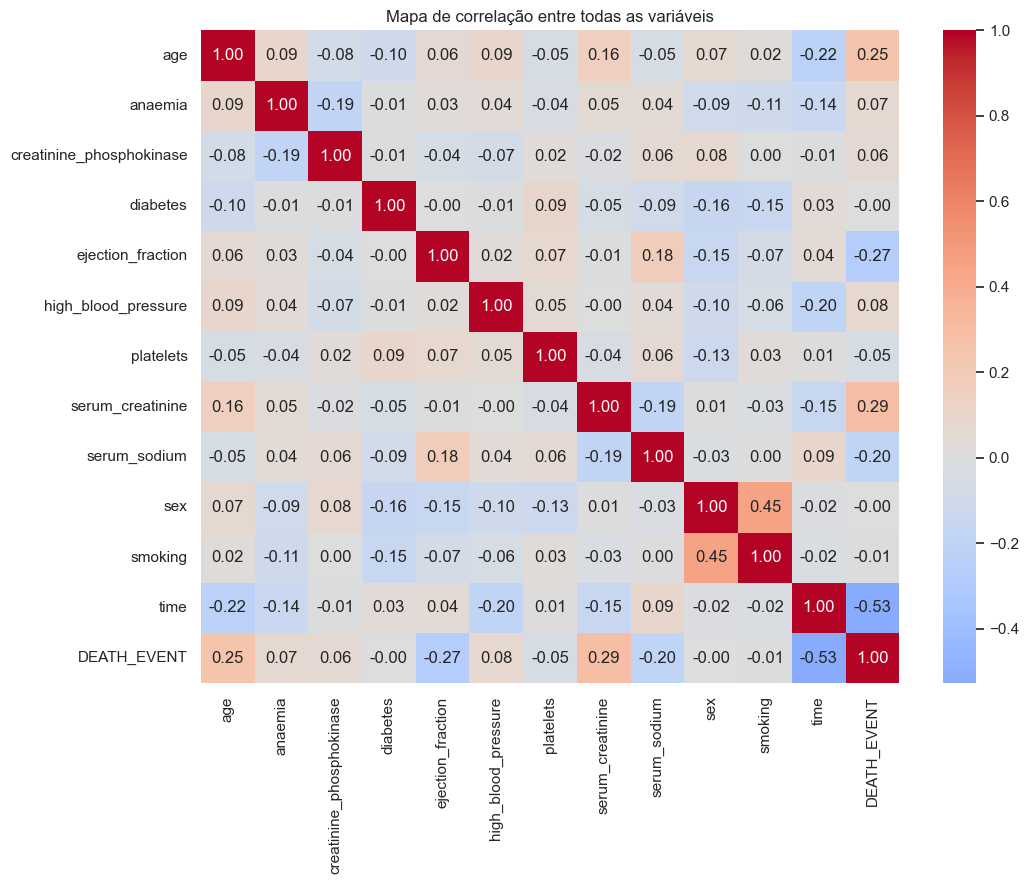

In [40]:
plt.figure(figsize=(11, 9))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Mapa de correlação entre todas as variáveis")
plt.tight_layout()
plt.show()

Embora time apresente a maior correlação com o óbito (-0.53), trata-se de data leakage: o tempo de acompanhamento é consequência do desfecho, não causa. Por isso, deve ser excluída de um eventual modelo preditivo, e os verdadeiros fatores de risco clínico são fração de ejeção, creatinina sérica e idade.

# **Conclusão**

**Fatores de risco identificados:**

A análise exploratória revelou três variáveis clínicas associadas ao óbito por insuficiência cardíaca. A fração de ejeção mostrou-se o principal fator: pacientes que faleceram tinham média de 33,5% contra 40,3% dos sobreviventes (correlação -0,27), confirmando que a menor capacidade de bombeamento do coração eleva o risco de morte. A creatinina sérica foi o segundo fator mais relevante (correlação +0,29): quem faleceu apresentava níveis 55% maiores (1,84 vs 1,18), indicando que o comprometimento da função renal acompanha o agravamento do quadro cardíaco. Por fim, a idade teve influência moderada — os que faleceram eram em média 6 anos mais velhos (65 vs 59 anos).

**Variáveis que surpreenderam por não importar:**

Condições normalmente associadas a problemas cardíacos mostraram correlação praticamente nula com o desfecho neste conjunto: diabetes (-0,00), sexo (-0,00), tabagismo (-0,01) e plaquetas (-0,05). Isso sugere que, nesta amostra específica, esses fatores isolados não distinguem quem sobrevive de quem falece.

**A armadilha do data leakage:**

A variável time (dias de acompanhamento) apresentou a maior correlação do dataset com o óbito (-0,53), mas trata-se de vazamento de dados: o tempo de acompanhamento é consequência do desfecho, não causa — pacientes que morreram cedo tiveram, por definição, menos dias de observação. Incluí-la em um modelo preditivo geraria uma performance artificialmente alta e inútil na prática, já que esse valor é desconhecido no momento de avaliar um paciente novo. Portanto, time deve ser descartada de qualquer modelo de previsão.

**Hipótese e próximos passos:**

Os dados sugerem que o risco de óbito é guiado pela gravidade da disfunção cardíaca (fração de ejeção) somada ao comprometimento renal (creatinina) e à idade. Para um projeto de Machine Learning, o modelo deveria usar essas variáveis clínicas, excluir time, e tratar o desbalanceamento da base (68% sobreviventes vs 32% óbitos) com técnicas apropriadas e métricas além da acurácia.